# 🚀 Breast Cancer Classification: Ensemble Learning Benchmark
**Objective:** Compare the performance of various **Ensemble Learning** techniques (Voting, Bagging, Random Forest, and Boosting) on the Breast Cancer dataset. Ensemble methods combine multiple weak learners to create a highly accurate and robust predictive model.

In [1]:
# 1. Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Import Ensemble Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (VotingClassifier, BaggingClassifier, 
                              RandomForestClassifier, AdaBoostClassifier, 
                              GradientBoostingClassifier)
from xgboost import XGBClassifier

print(" Libraries Imported Successfully")

 Libraries Imported Successfully


---
### 📂 Step 1: Load Data, Clean & Encode Target
XGBoost strictly requires the target variable to be numerical (0 and 1). We will apply `LabelEncoder` to the target right after loading.

In [2]:
# Load Dataset
df = pd.read_csv('Cancer_Data.csv')

# Drop irrelevant columns
columns_to_drop = ['id', 'Unnamed: 32']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

# Separate Features (X) and Target (y)
X = df.drop('diagnosis', axis=1)

# Encode Target: B -> 0, M -> 1 (Crucial for XGBoost)
le = LabelEncoder()
y = le.fit_transform(df['diagnosis'])

print(f"Features Shape: {X.shape}")

Features Shape: (569, 30)


---
### ✂️ Step 2: Data Splitting & Preprocessing
Since we are using linear models (Logistic Regression, SVC) inside our Ensemble voting/bagging classifiers, **Standardization is mandatory**. We will scale the data before feeding it into the models.

In [3]:
# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Data Split and Scaled Successfully!")

 Data Split and Scaled Successfully!


---
### 🏗️ Step 3: Define the Ensemble Models Dictionary
We define a dictionary containing all our advanced ensemble classifiers. This allows us to train and evaluate them programmatically using a loop.

In [4]:
# Define Base Estimators for Voting Classifier
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
lr = LogisticRegression(random_state=42)
svc = SVC(probability=True, random_state=42)

# Dictionary of all models
models = {
    "Hard Voting": VotingClassifier(estimators=[('dt', dt), ('lr', lr), ('svc', svc)], voting='hard'),
    "Soft Voting": VotingClassifier(estimators=[('dt', dt), ('lr', lr), ('svc', svc)], voting='soft'),
    "Bagging (LogReg)": BaggingClassifier(estimator=lr, n_estimators=30, bootstrap=True, random_state=42),
    "Pasting (LogReg)": BaggingClassifier(estimator=lr, n_estimators=30, bootstrap=False, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=4, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=50, eval_metric='logloss', random_state=42)
}

print(" All 8 Ensemble Models Initialized!")

 All 8 Ensemble Models Initialized!


---
### 🚀 Step 4: Train, Evaluate & Benchmark
We iterate through our dictionary, train each model, predict the test set, and store the accuracy results for comparison.

⏳ Training and Evaluating Models...

✔️ Hard Voting          Accuracy: 97.37%
✔️ Soft Voting          Accuracy: 96.49%
✔️ Bagging (LogReg)     Accuracy: 96.49%
✔️ Pasting (LogReg)     Accuracy: 96.49%
✔️ Random Forest        Accuracy: 95.61%
✔️ AdaBoost             Accuracy: 98.25%
✔️ Gradient Boosting    Accuracy: 95.61%
✔️ XGBoost              Accuracy: 95.61%


C:\Users\ahmed\AppData\Local\Temp\ipykernel_4368\25296176.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sorted_results.values()), y=list(sorted_results.keys()), palette='viridis')


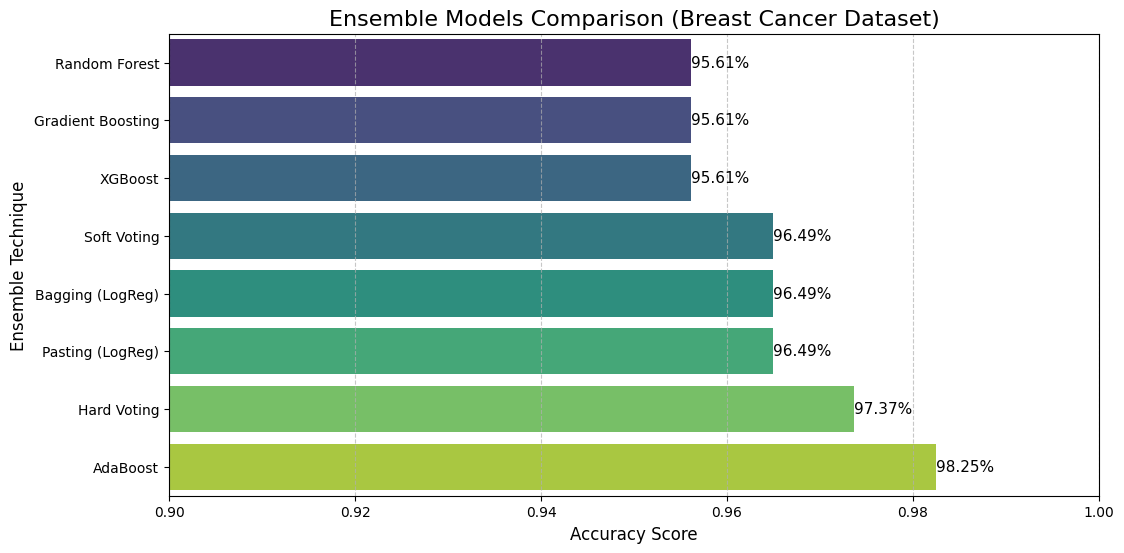

In [5]:
# Dictionary to store accuracy scores
accuracy_results = {}

print("⏳ Training and Evaluating Models...\n")

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Calculate Accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc
    
    print(f"✔️ {name:20s} Accuracy: {acc * 100:.2f}%")

# ==========================================
# 📊 Visualizing the Benchmark Results
# ==========================================
plt.figure(figsize=(12, 6))

# Sort results for better visualization
sorted_results = dict(sorted(accuracy_results.items(), key=lambda item: item[1]))

# Create Bar Plot
sns.barplot(x=list(sorted_results.values()), y=list(sorted_results.keys()), palette='viridis')

plt.title('Ensemble Models Comparison (Breast Cancer Dataset)', fontsize=16)
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Ensemble Technique', fontsize=12)
plt.xlim(0.9, 1.0) # Zoom in to see the slight differences between highly accurate models
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels to the bars
for index, value in enumerate(sorted_results.values()):
    plt.text(value, index, f"{value*100:.2f}%", va='center', fontsize=11)

plt.show()